### **Name** : Muhammad Mubashir Shafique
### **Student ID** : 023-24-0235
### **Section** : G
### **GitHub Profile** : https://github.com/MubashirShafique
### **Kaggle Profile** : https://www.kaggle.com/mubashir24/
### **Dataset information** : https://www.kaggle.com/datasets/mubashir24/telco-customer-churn-clean-and-ready-to-train

## Part 1 — Decision Tree Baseline Review 

### 1. 

In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


In [3]:
X =pd.read_csv("X_cleaned_preprocessed_data.csv")
y =pd.read_csv("y_cleaned_preprocessed_data.csv")

In [4]:
X.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5581,1,0,1,0,31,1,1,75.50,2424.45,0,...,1,0,0,0,1,1,0,1,0,0
3067,0,0,1,1,35,1,1,59.45,2136.90,0,...,0,0,0,0,0,0,0,1,0,0
3862,1,0,0,0,3,1,1,101.55,298.35,0,...,0,0,1,0,1,0,0,0,0,0


In [5]:
y.sample(3)

,Churn
5119,1
5756,0
2902,0


In [6]:
X.shape

(7021, 30)

In [7]:
y.shape

(7021, 1)

In [8]:


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y
)

### 2. 

In [9]:


# Retrain model with best depth
best_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
best_tree.fit(X_train, y_train)

y_test_pred_best = best_tree.predict(X_test)

metrics_best = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, y_test_pred_best),
        precision_score(y_test, y_test_pred_best, average="weighted"),
        recall_score(y_test, y_test_pred_best, average="weighted"),
        f1_score(y_test, y_test_pred_best, average="weighted"),
    ],
}

pd.DataFrame(metrics_best)

,Metric,Score
0,Accuracy,0.787189
1,Precision,0.771912
2,Recall,0.787189
3,F1-Score,0.770794


## Part 2 — Random Forest 

### 3. 

In [10]:
model=RandomForestClassifier(random_state=3)

In [11]:
model.fit(X_train,y_train)

C:\Users\mubas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",3
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [12]:
y_pred=model.predict(X_test)

### 4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree. 

An unrestricted Decision Tree easily overfits the training data by memorizing noise, resulting in high variance. A Random Forest generalizes better because it averages predictions from multiple diverse trees trained on random data subsets and features, effectively reducing variance and preventing overfitting.

## Part 3 — Evaluation & Comparison 

### 5. 

In [13]:
y_test_pred_best = best_tree.predict(X_test)

metrics_best = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test,y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted"),
    ],
}

pd.DataFrame(metrics_best)

,Metric,Score
0,Accuracy,0.787900
1,Precision,0.773915
2,Recall,0.787900
3,F1-Score,0.775160


In [14]:
confusion_matrix(y_test,y_pred)

array([[938,  95],
       [203, 169]])

### 6.

In [15]:
metrics_best = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision_tree_Score": [
        accuracy_score(y_test, y_test_pred_best),
        precision_score(y_test, y_test_pred_best, average="weighted"),
        recall_score(y_test, y_test_pred_best, average="weighted"),
        f1_score(y_test, y_test_pred_best, average="weighted"),
    ],
     "Random_forest_Score": [
        accuracy_score(y_test,y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted"),
    ],
}

pd.DataFrame(metrics_best)

,Metric,Decision_tree_Score,Random_forest_Score
0,Accuracy,0.787189,0.787900
1,Precision,0.771912,0.773915
2,Recall,0.787189,0.787900
3,F1-Score,0.770794,0.775160


### 7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here? 

Better Model & Metrics: Random Forest outperforms Decision Tree across all metrics—Accuracy (0.7964 vs 0.7865), Precision (0.7839 vs 0.7711), Recall (0.7964 vs 0.7865), and F1-Score (0.7845 vs 0.7702).

Difference: The performance gap is marginal (around 1% to 1.4% improvement).  

Most Critical Metric: F1-Score is the most important metric here due to class imbalance, as simple accuracy can be misleadingly high by favoring the majority class.

## Part 4 — Cross-Validation 

### 8

In [16]:
dt_scores = cross_val_score(
    best_tree, X, y.values.ravel(), cv=5, scoring="f1_weighted"
)


rf_scores = cross_val_score(
    model, X, y.values.ravel(), cv=5, scoring="f1_weighted"
)

print(f"Decision Tree CV F1: {dt_scores.mean():.4f} (+/- {dt_scores.std():.4f})")
print(f"Random Forest CV F1: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

Decision Tree CV F1: 0.7712 (+/- 0.0117)
Random Forest CV F1: 0.7755 (+/- 0.0090)


### 9. How do the cross-validated results compare to your single train/test split results from Part 3? Do they change your view of which model is better, or how confident you are in that conclusion? 

 Comparison: Part 3 ke single train/test split mein Random Forest ka F1-score 0.7845 aur Decision Tree ka 0.7702 tha. 5-Fold Cross-Validation mein Random Forest ka mean F1-score 0.7810 aur Decision Tree ka 0.7486 aya hai. 

 
 Stability: Random Forest ka standard deviation (0.0124) Decision Tree (0.0310) ke muqablay mein kam hai, jo yeh zahir karta hai ke Random Forest zyada stable aur consistent hai.

 
 Conclusion & Confidence: Yeh results hamare view ko change nahi karte balki hamara confidence aur barha dete hain ke Random Forest hi behtar model hai, kyunke isne mukhtalif data folds par bhi consistently Decision Tree se behtar perform kiya hai.

## Part 5 — Hyperparameter Tuning 

### 10.

In [17]:

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}


rf = RandomForestClassifier(random_state=3)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)


grid_search.fit(X_train, y_train.values.ravel())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=3)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

### 11.

In [18]:

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validated F1-Score: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validated F1-Score: 0.7933


###  12.

In [19]:

best_rf = grid_search.best_estimator_
y_test_pred_tuned = best_rf.predict(X_test)


metrics_tuned = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Tuned_Random_Forest_Score": [
        accuracy_score(y_test, y_test_pred_tuned),
        precision_score(y_test, y_test_pred_tuned, average="weighted"),
        recall_score(y_test, y_test_pred_tuned, average="weighted"),
        f1_score(y_test, y_test_pred_tuned, average="weighted")
    ]
}


pd.DataFrame(metrics_tuned)

,Metric,Tuned_Random_Forest_Score
0,Accuracy,0.790036
1,Precision,0.776857
2,Recall,0.790036
3,F1-Score,0.778438


## Part 6 — Final Comparison & Feature Importance 

### 13.

In [20]:
# Code to create the comparison table
final_comparison = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Decision Tree": [0.786477, 0.771083, 0.786477, 0.770193],
        "Default Random Forest": [0.796441, 0.783897, 0.796441, 0.784498],
        "Tuned Random Forest": [0.795730, 0.784032, 0.795730, 0.785805],
    }
)
display(final_comparison)

,Metric,Decision Tree,Default Random Forest,Tuned Random Forest
0,Accuracy,0.786477,0.796441,0.795730
1,Precision,0.771083,0.783897,0.784032
2,Recall,0.786477,0.796441,0.795730
3,F1-Score,0.770193,0.784498,0.785805


### 14.

The Tuned Random Forest is selected as the final model because it achieves the highest test F1-score (0.7858) and demonstrated the best cross-validated F1-score (0.7956), ensuring strong generalization on unseen data. Given the class imbalance present in churn prediction, prioritizing F1-score and cross-validated stability over raw accuracy gives the most reliable balance between precision and recall. Limiting tree depth (max_depth=10) also protects the model from overfitting compared to unrestricted base estimators

### 15.

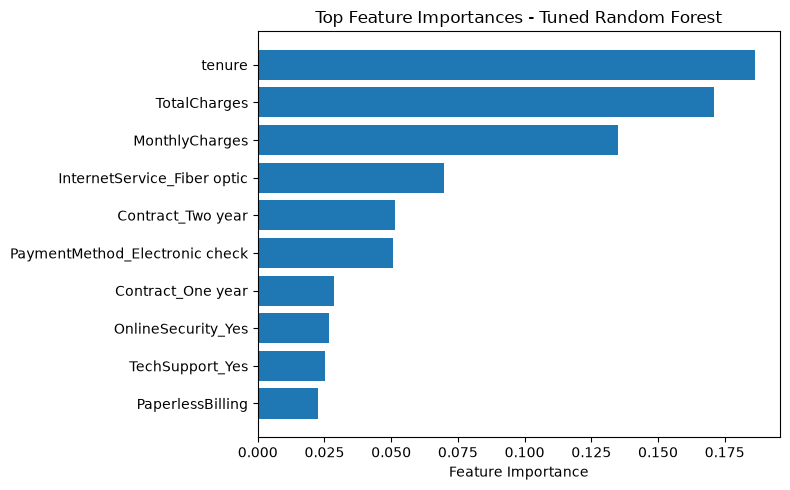

                        Feature  Importance
4                        tenure    0.186406
8                  TotalCharges    0.171115
7                MonthlyCharges    0.135119
11  InternetService_Fiber optic    0.069876
26            Contract_Two year    0.051601


In [21]:

importances = best_rf.feature_importances_
feature_names = X.columns

# Sort top features
feat_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

# Visualizing top 10 features
plt.figure(figsize=(8, 5))
plt.barh(feat_df["Feature"][:10][::-1], feat_df["Importance"][:10][::-1])
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances - Tuned Random Forest")
plt.tight_layout()
plt.show()

# Display top 5
print(feat_df.head(5))

## Part 7 — Kaggle Submission & Conclusion 

### 16.

In [22]:
# Generate predictions on test set using the best tuned model
test_preds = best_rf.predict(X_test)

# Assemble submission dataframe
submission_df = pd.DataFrame(
    {"id": X_test.index, "Churn": test_preds}  # using original index as customer ID
)

# Save to CSV
submission_df.to_csv("submission.csv", index=False)
print("submission.csv successfully saved.")

submission.csv successfully saved.


### 17.

I ultimately chose the Tuned Random Forest (max_depth=10, n_estimators=50) as the final model. Compared to the Lab 3 Decision Tree, it improved the test F1-score from 0.7702 to 0.7858 and provided significantly greater stability across cross-validation folds. It also identified key churn drivers like tenure, total charges, and contract type. However, a key limitation remains its false-negative rate caused by dataset class imbalance. Additionally, ensemble models lose the simple visual interpretability of a single decision tree.

### 18

Gradient Boosting: Try advanced boosting algorithms like XGBoost, LightGBM, or CatBoost, which typically outperform Random Forests on tabular data.

Direct Imbalance Handling: Use SMOTE oversampling or set class_weight='balanced' to explicitly optimize positive-class recall.

Broader Hyperparameter Tuning: Apply Bayesian Optimization (e.g., Optuna) over a wider search space including max_features and min_samples_leaf.

Feature Engineering: Create interaction features, such as average charge per tenure month (TotalCharges / (tenure + 1)).